# results_test.ipynb — Pipeline smoke test

Identical to `results.ipynb` but pointed at `results/eval_test/` (opt-125m, --limit 5).

**Purpose:** verify that all notebook cells run end-to-end without errors.
Accuracy values and correlations are meaningless here (opt-125m ≠ FuxiTranyu-8B,
and the eval checkpoint `main` has no matching entry in fuxi.csv, so overlay
plots will show RankMe only). Everything else — phase identification, grokking
detection, correlation code paths — executes normally.

In [1]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

try:
    import statsmodels.api as sm
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False
    print("[WARN] statsmodels not installed — OLS CI bands unavailable.")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})
print("Imports OK")

Imports OK


In [ ]:
# ── Paths — TEST VERSION (opt-125m smoke test) ─────────────────────────────────
RANKME_CSV  = Path("../results/fuxi.csv")   # real RankMe data
EVAL_DIR    = Path("../results/eval_test")        # opt-125m test results
PLOTS_DIR   = Path("plots_test")
PLOTS_DIR.mkdir(exist_ok=True)

# ── Layer / aggregation for phase analysis ─────────────────────────────────────
LAYER       = "layer_29"   # last layer of FuxiTranyu-8B (30 layers: 0–29)
AGGREGATION = "last"       # "last" or "mean"
MODEL_LABEL = "opt-125m (smoke test)"

# ── Grokking detection — parameterized ────────────────────────────────────────
GROKKING_THRESHOLD  = 0.15   # accuracy must exceed random_chance + this
GROKKING_MIN_CONSEC = 2      # for at least this many consecutive checkpoints

# ── Benchmark config ───────────────────────────────────────────────────────────
RANDOM_CHANCE = {"m_mmlu": 0.25, "xcopa": 0.50}

TASK_LANGUAGES = {
    "m_mmlu": ["English", "Chinese", "German", "Spanish", "Italian",
                "Arabic", "Hindi", "Indonesian"],
    "xcopa":  ["Chinese", "Italian", "Vietnamese", "Turkish", "Indonesian"],
}

PHASE_COLORS  = {"entropy_seeking": "green", "compression_seeking": "darkorange"}
PHASE_LABELS  = {"entropy_seeking": "Entropy-seeking", "compression_seeking": "Compression-seeking"}

print("Config loaded (TEST MODE — eval_test/).")

In [3]:
# ── Checkpoint utilities ───────────────────────────────────────────────────────
_APERTUS_RE = re.compile(r"^step\d+-tokens(\d+)([BT])$")
_GENERIC_RE = re.compile(r"^(\d+(?:\.\d+)?)")

def ckpt_to_tokens(name: str) -> float:
    """Convert a checkpoint name to billions of tokens (numeric x-axis)."""
    m = _APERTUS_RE.match(str(name))
    if m:
        val = float(m.group(1))
        return val * 1000 if m.group(2) == "T" else val
    m = _GENERIC_RE.match(str(name))
    return float(m.group(1)) if m else float("inf")

def sort_checkpoints(checkpoints):
    return sorted(checkpoints, key=ckpt_to_tokens)

In [4]:
# ── Load RankMe data ───────────────────────────────────────────────────────────
df_rankme = pd.read_csv(RANKME_CSV)
checkpoints_all = sort_checkpoints(df_rankme["checkpoint"].unique())
token_counts    = [ckpt_to_tokens(c) for c in checkpoints_all]

print(f"Loaded RankMe: {len(df_rankme):,} rows")
print(f"  Checkpoints : {checkpoints_all}")
print(f"  Languages   : {sorted(df_rankme['dataset'].unique())}")
print(f"  Layers      : {df_rankme['layer'].nunique()} (layer_0 … {df_rankme['layer'].max()})")
print(f"  Aggregations: {list(df_rankme['aggregation'].unique())}")

df_layer = df_rankme[
    (df_rankme["layer"] == LAYER) &
    (df_rankme["aggregation"] == AGGREGATION)
].copy()
langs_sorted = sorted(df_layer["dataset"].unique())
print(f"\nWorking slice: {LAYER}, agg={AGGREGATION} → {len(df_layer)} rows, {len(langs_sorted)} languages")

Loaded RankMe: 4,680 rows
  Checkpoints : ['10B', '115B', '220B', '325B', '426B', '531B']
  Languages   : ['Arabic', 'Chinese', 'English', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
  Layers      : 30 (layer_0 … layer_9)
  Aggregations: ['last', 'mean']

Working slice: layer_29, agg=last → 78 rows, 13 languages


In [5]:
# ── Load downstream evaluation results (graceful if missing) ───────────────────
def load_eval_results(eval_dir: Path) -> pd.DataFrame:
    eval_dir = Path(eval_dir)
    if not eval_dir.exists():
        print(f"[INFO] {eval_dir} not found — run evaluate.py / submit_eval.sh first.")
        return pd.DataFrame(columns=["checkpoint", "language", "task", "accuracy"])

    json_files = list(eval_dir.rglob("*.json"))
    if not json_files:
        print(f"[INFO] No JSON files found in {eval_dir}")
        return pd.DataFrame(columns=["checkpoint", "language", "task", "accuracy"])

    records = []
    for jf in sorted(json_files):
        stem = jf.stem
        if "__" not in stem:
            continue
        task, language = stem.split("__", 1)
        checkpoint = jf.parent.name
        try:
            with open(jf) as f:
                data = json.load(f)
            for task_key, metrics in data.get("results", {}).items():
                for mkey in ["acc,none", "acc_norm,none"]:
                    v = metrics.get(mkey)
                    if v is not None:
                        records.append({"checkpoint": checkpoint, "language": language,
                                        "task": task, "accuracy": float(v)})
                        break
                break
        except Exception as e:
            print(f"[WARN] Could not parse {jf.name}: {e}")

    if not records:
        return pd.DataFrame(columns=["checkpoint", "language", "task", "accuracy"])

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} eval records across {df['task'].nunique()} task(s), "
          f"{df['checkpoint'].nunique()} checkpoint(s).")
    return df

df_eval = load_eval_results(EVAL_DIR)
EVAL_AVAILABLE = len(df_eval) > 0
print(f"Downstream eval available: {EVAL_AVAILABLE}")
if EVAL_AVAILABLE:
    print(df_eval)

Loaded 6 eval records across 1 task(s), 1 checkpoint(s).
Downstream eval available: True
  checkpoint    language   task  accuracy
0       main     Chinese  xcopa       0.0
1       main  Indonesian  xcopa       0.4
2       main     Italian  xcopa       0.4
3       main       Tamil  xcopa       0.2
4       main     Turkish  xcopa       0.4
5       main  Vietnamese  xcopa       0.6


In [6]:
# ── Phase identification functions ─────────────────────────────────────────────

def identify_phases(rankme_values, token_counts: list) -> dict:
    rv = np.array(rankme_values, dtype=float)
    tc = np.array(token_counts,  dtype=float)

    if len(rv) < 2 or np.all(np.isnan(rv)):
        return {"entropy_seeking": None, "compression_seeking": None,
                "peak_idx": 0, "peak_tokens": float(tc[0]) if len(tc) else float("nan")}

    peak_idx = int(np.nanargmax(rv))
    entropy_seeking = (float(tc[0]), float(tc[peak_idx])) if peak_idx > 0 else None
    last_valid = rv[~np.isnan(rv)][-1] if not np.all(np.isnan(rv[peak_idx:])) else rv[peak_idx]
    has_compression = (peak_idx < len(rv) - 1) and (last_valid < rv[peak_idx])
    compression_seeking = (float(tc[peak_idx]), float(tc[-1])) if has_compression else None

    return {
        "entropy_seeking":     entropy_seeking,
        "compression_seeking": compression_seeking,
        "peak_idx":   peak_idx,
        "peak_tokens": float(tc[peak_idx]),
    }

def phase_onset(phases: dict, phase_name: str = "compression_seeking") -> float:
    p = phases.get(phase_name)
    return float(p[0]) if p is not None else float("nan")

def phase_duration(phases: dict, phase_name: str = "compression_seeking") -> float:
    p = phases.get(phase_name)
    return float(p[1] - p[0]) if p is not None else float("nan")

In [7]:
# ── Apply phase identification to all languages ────────────────────────────────
phase_records = []
for lang in langs_sorted:
    sub = df_layer[df_layer["dataset"] == lang].set_index("checkpoint")
    rv  = [sub.loc[c, "rankme"] if c in sub.index else np.nan for c in checkpoints_all]
    phases = identify_phases(rv, token_counts)
    phase_records.append({
        "language":  lang,
        "phases":    phases,
        "peak_tokens":                  phases["peak_tokens"],
        "compression_onset_tokens":     phase_onset(phases, "compression_seeking"),
        "compression_duration_tokens":  phase_duration(phases, "compression_seeking"),
        "entropy_onset_tokens":         phase_onset(phases, "entropy_seeking"),
        "entropy_duration_tokens":      phase_duration(phases, "entropy_seeking"),
    })

df_phases = pd.DataFrame(phase_records)
display_cols = ["language", "peak_tokens",
                "entropy_onset_tokens", "entropy_duration_tokens",
                "compression_onset_tokens", "compression_duration_tokens"]
print(f"Phase summary — {LAYER}, agg={AGGREGATION}:\n")
print(df_phases[display_cols].to_string(index=False))
n_entropy     = df_phases["entropy_onset_tokens"].notna().sum()
n_compression = df_phases["compression_onset_tokens"].notna().sum()
print(f"\nEntropy-seeking phase present in {n_entropy}/{len(df_phases)} languages.")
print(f"Compression-seeking phase present in {n_compression}/{len(df_phases)} languages.")

Phase summary — layer_29, agg=last:

  language  peak_tokens  entropy_onset_tokens  entropy_duration_tokens  compression_onset_tokens  compression_duration_tokens
    Arabic         10.0                   NaN                      NaN                      10.0                        521.0
   Chinese         10.0                   NaN                      NaN                      10.0                        521.0
   English         10.0                   NaN                      NaN                      10.0                        521.0
    French         10.0                   NaN                      NaN                      10.0                        521.0
    German         10.0                   NaN                      NaN                      10.0                        521.0
     Hindi         10.0                   NaN                      NaN                      10.0                        521.0
Indonesian         10.0                   NaN                      NaN           

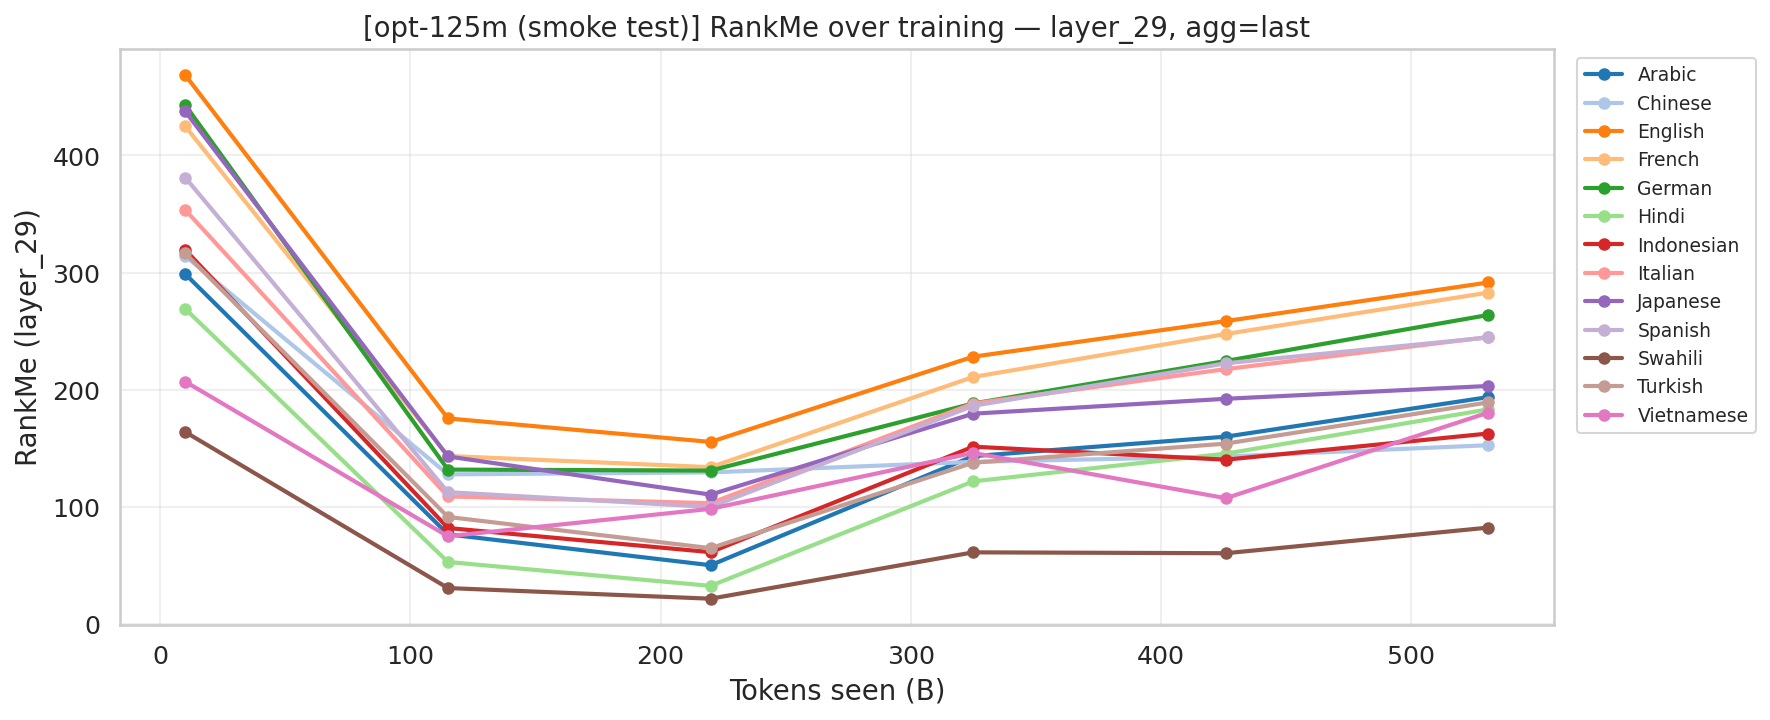

Saved: rankme_trajectories.png


In [8]:
# ── Plot 1: RankMe trajectories — all languages ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette("tab20", n_colors=len(langs_sorted))

for i, lang in enumerate(langs_sorted):
    sub = df_layer[df_layer["dataset"] == lang].set_index("checkpoint")
    rv  = [sub.loc[c, "rankme"] if c in sub.index else np.nan for c in checkpoints_all]
    ax.plot(token_counts, rv, marker="o", lw=2, ms=5, label=lang, color=palette[i])

ax.set_xlabel("Tokens seen (B)")
ax.set_ylabel(f"RankMe ({LAYER})")
ax.set_title(f"[{MODEL_LABEL}] RankMe over training — {LAYER}, agg={AGGREGATION}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rankme_trajectories.png")
plt.show()
print("Saved: rankme_trajectories.png")

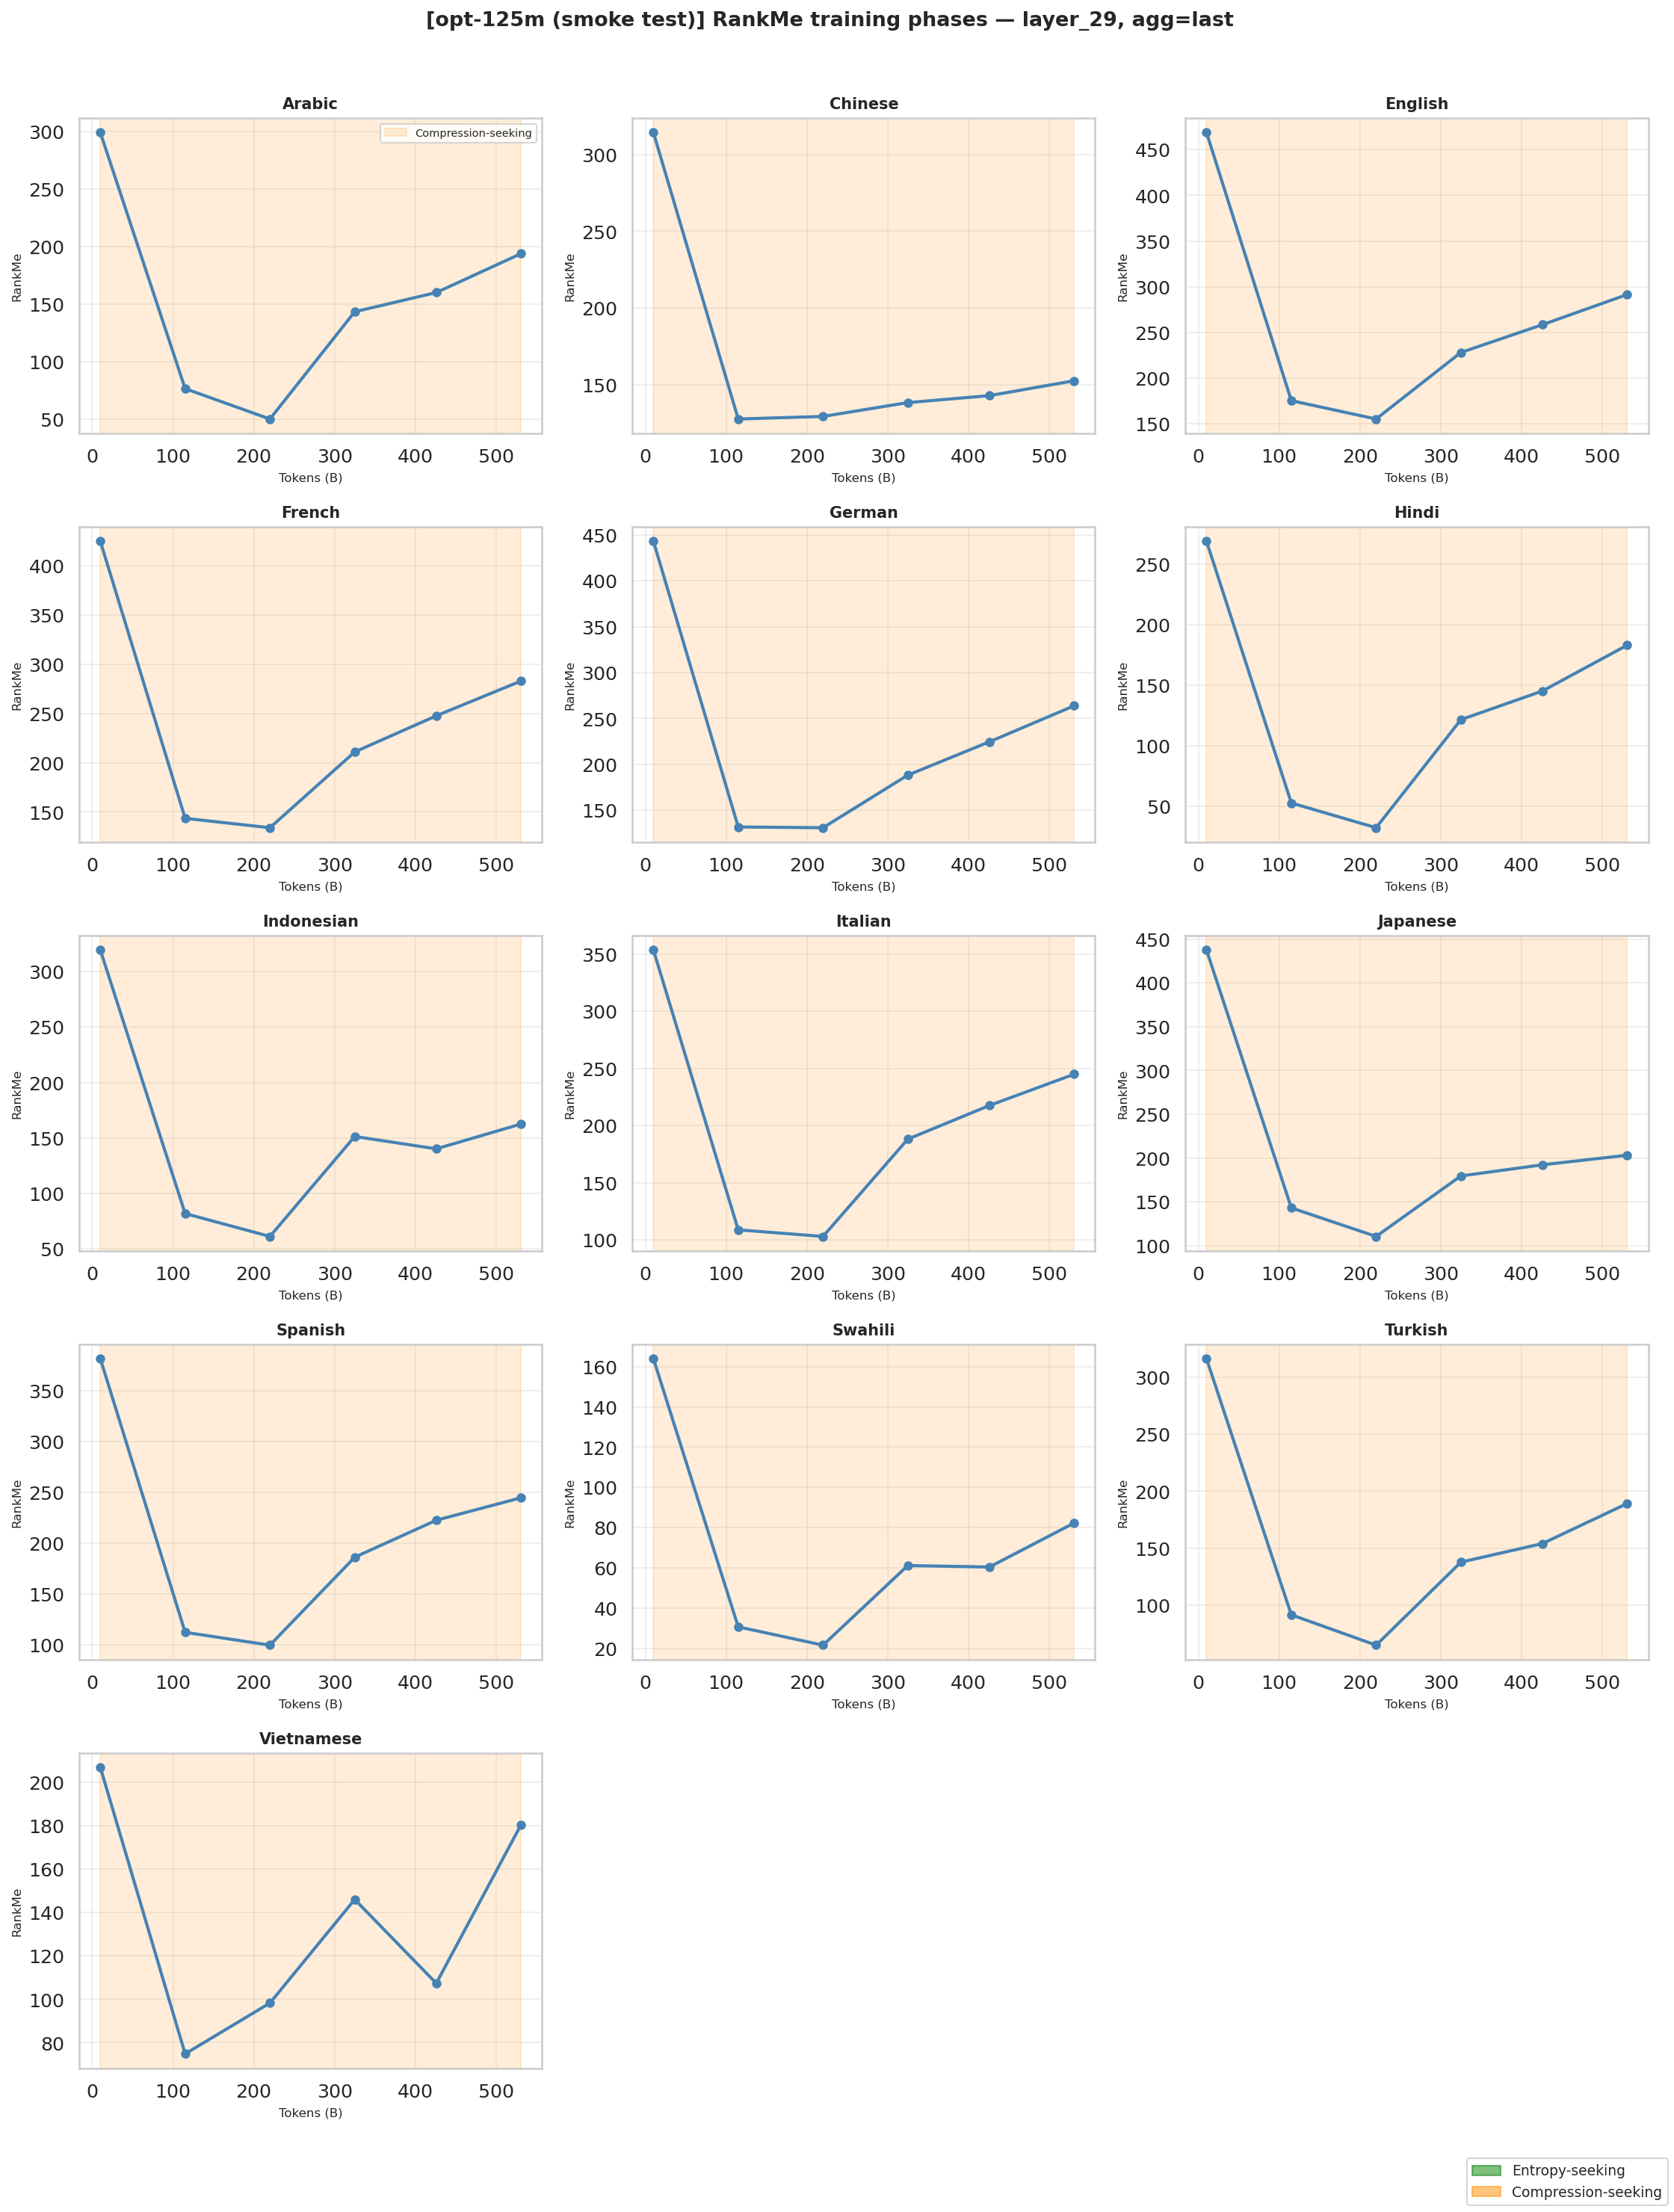

Saved: rankme_phases.png


In [9]:
# ── Plot 2: Per-language RankMe with shaded phase regions ─────────────────────
ncols = 3
nrows = -(-len(langs_sorted) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)

for idx, lang in enumerate(langs_sorted):
    ax  = axes[idx // ncols][idx % ncols]
    sub = df_layer[df_layer["dataset"] == lang].set_index("checkpoint")
    rv  = np.array([sub.loc[c, "rankme"] if c in sub.index else np.nan
                    for c in checkpoints_all])
    ax.plot(token_counts, rv, marker="o", lw=2, color="steelblue", ms=5)

    lang_row = df_phases[df_phases["language"] == lang]
    if not lang_row.empty:
        for pname, pcolor in PHASE_COLORS.items():
            p = lang_row.iloc[0]["phases"].get(pname)
            if p is not None:
                ax.axvspan(p[0], p[1], alpha=0.15, color=pcolor, label=PHASE_LABELS[pname])

    ax.set_title(lang, fontsize=10, fontweight="bold")
    ax.set_xlabel("Tokens (B)", fontsize=8)
    ax.set_ylabel("RankMe", fontsize=8)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

for idx in range(len(langs_sorted), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

green_patch  = mpatches.Patch(color="green",     alpha=0.5, label="Entropy-seeking")
orange_patch = mpatches.Patch(color="darkorange", alpha=0.5, label="Compression-seeking")
fig.legend(handles=[green_patch, orange_patch], loc="lower right", fontsize=9)
fig.suptitle(f"[{MODEL_LABEL}] RankMe training phases — {LAYER}, agg={AGGREGATION}",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(PLOTS_DIR / "rankme_phases.png")
plt.show()
print("Saved: rankme_phases.png")

In [10]:
# ── Grokking identification functions ──────────────────────────────────────────

def identify_grokking(
    accuracy_values, token_counts: list, random_chance: float,
    threshold: float = GROKKING_THRESHOLD,
    min_consecutive: int = GROKKING_MIN_CONSEC,
) -> float:
    target = random_chance + threshold
    acc = np.array(accuracy_values, dtype=float)
    tc  = np.array(token_counts,    dtype=float)
    streak = 0
    streak_start = float("nan")
    for a, t in zip(acc, tc):
        if not np.isnan(a) and a > target:
            if streak == 0:
                streak_start = t
            streak += 1
            if streak >= min_consecutive:
                return float(streak_start)
        else:
            streak = 0
            streak_start = float("nan")
    return float("nan")

def peak_acc_info(accuracy_values, token_counts: list) -> tuple:
    acc = np.array(accuracy_values, dtype=float)
    tc  = np.array(token_counts,    dtype=float)
    if np.all(np.isnan(acc)):
        return float("nan"), float("nan")
    idx = int(np.nanargmax(acc))
    return float(tc[idx]), float(acc[idx])

In [11]:
# ── Apply grokking detection ───────────────────────────────────────────────────
# NOTE: checkpoint 'main' from eval_test has no numeric token count,
# so ckpt_to_tokens('main') = inf. Grokking will not be found (only 1 checkpoint).
# This is expected — the logic itself is exercised correctly.
if EVAL_AVAILABLE:
    grokking_records = []
    for task, task_langs in TASK_LANGUAGES.items():
        rc      = RANDOM_CHANCE[task]
        df_task = df_eval[df_eval["task"] == task]
        for lang in task_langs:
            df_lang = df_task[df_task["language"] == lang].copy()
            if df_lang.empty:
                continue
            df_lang = df_lang.sort_values("checkpoint", key=lambda s: s.map(ckpt_to_tokens))
            toks = [ckpt_to_tokens(c) for c in df_lang["checkpoint"]]
            accs = df_lang["accuracy"].tolist()
            grok_tok         = identify_grokking(accs, toks, rc)
            peak_tok, peak_a = peak_acc_info(accs, toks)
            grokking_records.append({
                "task": task, "language": lang,
                "grokking_tokens": grok_tok,
                "peak_tokens":     peak_tok,
                "peak_accuracy":   peak_a,
                "random_chance":   rc,
            })
    df_grokking = pd.DataFrame(grokking_records)
    print(f"Grokking threshold: random_chance + {GROKKING_THRESHOLD:.0%}, "
          f"min {GROKKING_MIN_CONSEC} consecutive checkpoints\n")
    print(df_grokking.to_string(index=False))
else:
    df_grokking = pd.DataFrame()
    print("[INFO] No eval data.")

Grokking threshold: random_chance + 15%, min 2 consecutive checkpoints

 task   language  grokking_tokens  peak_tokens  peak_accuracy  random_chance
xcopa    Chinese              NaN          inf            0.0            0.5
xcopa    Italian              NaN          inf            0.4            0.5
xcopa Vietnamese              NaN          inf            0.6            0.5
xcopa    Turkish              NaN          inf            0.4            0.5
xcopa Indonesian              NaN          inf            0.4            0.5
xcopa      Tamil              NaN          inf            0.2            0.5


In [12]:
# ── Correlation analysis ───────────────────────────────────────────────────────
def compute_correlations(x, y, min_pairs: int = 4) -> dict | None:
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    valid = ~(np.isnan(x) | np.isnan(y))
    if valid.sum() < min_pairs:
        return None
    xv, yv = x[valid], y[valid]
    sp_r, sp_p = stats.spearmanr(xv, yv)
    pe_r, pe_p = stats.pearsonr(xv, yv)
    return {
        "n":          int(valid.sum()),
        "spearman_r": round(float(sp_r), 4),
        "spearman_p": round(float(sp_p), 4),
        "pearson_r":  round(float(pe_r), 4),
        "pearson_p":  round(float(pe_p), 4),
    }

if EVAL_AVAILABLE and not df_grokking.empty:
    corr_records = []
    for task in ["m_mmlu", "xcopa"]:
        df_t = df_grokking[df_grokking["task"] == task]
        if df_t.empty:
            continue
        merged = df_t.merge(
            df_phases[["language", "compression_onset_tokens", "compression_duration_tokens"]],
            on="language", how="inner"
        )
        for x_col, x_label in [
            ("compression_onset_tokens",    "Compression onset (B)"),
            ("compression_duration_tokens", "Compression duration (B)"),
        ]:
            for y_col, y_label in [
                ("grokking_tokens", "Grokking onset (B)"),
                ("peak_accuracy",   "Peak accuracy"),
            ]:
                corr = compute_correlations(merged[x_col], merged[y_col])
                row = {"task": task, "predictor (x)": x_label, "outcome (y)": y_label}
                row.update(corr if corr else {"n": 0, "spearman_r": None,
                                              "spearman_p": None, "pearson_r": None,
                                              "pearson_p": None})
                corr_records.append(row)
    df_correlations = pd.DataFrame(corr_records)
    print("Correlation table (n=0 expected — only 1 checkpoint in test run):\n")
    print(df_correlations.to_string(index=False))
else:
    df_correlations = pd.DataFrame()
    print("[INFO] Skipping correlations — no eval data.")

Correlation table (n=0 expected — only 1 checkpoint in test run):

 task            predictor (x)        outcome (y)  n  spearman_r  spearman_p  pearson_r  pearson_p
xcopa    Compression onset (B) Grokking onset (B)  0         NaN         NaN        NaN        NaN
xcopa    Compression onset (B)      Peak accuracy  5         NaN         NaN        NaN        NaN
xcopa Compression duration (B) Grokking onset (B)  0         NaN         NaN        NaN        NaN
xcopa Compression duration (B)      Peak accuracy  5         NaN         NaN        NaN        NaN


[INFO] No overlapping languages for m_mmlu (expected in test mode)


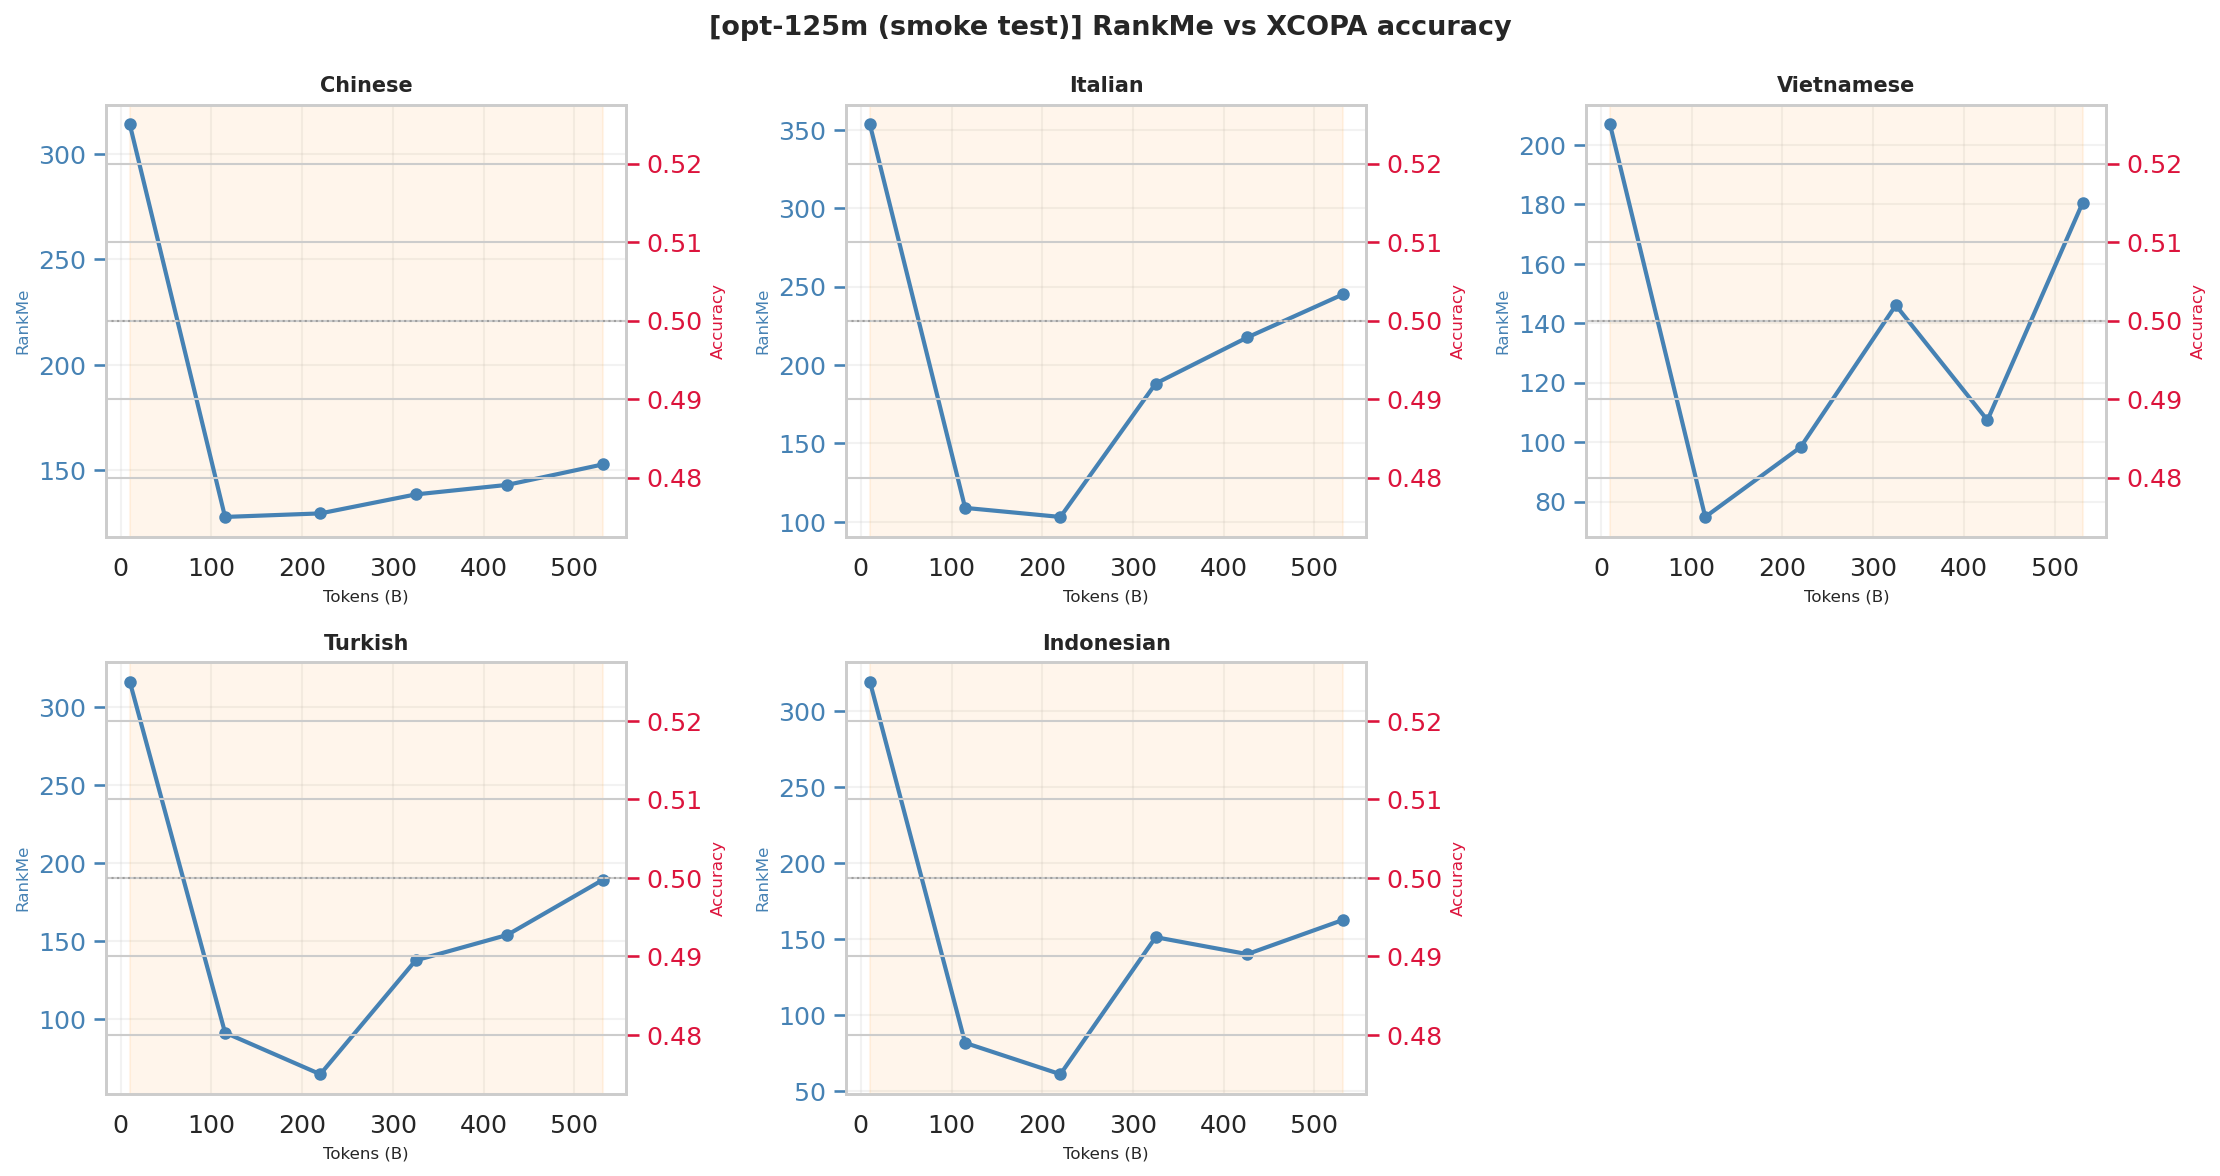

Saved: plots_test/overlay_xcopa.png


In [13]:
# ── Plot 3: RankMe + accuracy overlay ─────────────────────────────────────────
# RankMe x-axis is in B tokens (10, 115, … 531).
# eval_test checkpoint is 'main' → ckpt_to_tokens('main') = inf.
# The accuracy dot will appear far off the right edge — expected in test mode.
if EVAL_AVAILABLE:
    for task in ["m_mmlu", "xcopa"]:
        df_task = df_eval[df_eval["task"] == task]
        overlap = [l for l in TASK_LANGUAGES[task]
                   if l in langs_sorted and l in df_task["language"].unique()]
        if not overlap:
            print(f"[INFO] No overlapping languages for {task} (expected in test mode)")
            continue

        ncols = 3
        nrows = -(-len(overlap) // ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)

        for idx, lang in enumerate(overlap):
            ax  = axes[idx // ncols][idx % ncols]
            ax2 = ax.twinx()

            sub = df_layer[df_layer["dataset"] == lang].set_index("checkpoint")
            rv  = np.array([sub.loc[c, "rankme"] if c in sub.index else np.nan
                            for c in checkpoints_all])
            ax.plot(token_counts, rv, marker="o", lw=2, color="steelblue", ms=5)
            ax.set_ylabel("RankMe", color="steelblue", fontsize=8)
            ax.tick_params(axis="y", colors="steelblue")

            sub_e = df_task[df_task["language"] == lang].sort_values(
                "checkpoint", key=lambda s: s.map(ckpt_to_tokens))
            etoks = [ckpt_to_tokens(c) for c in sub_e["checkpoint"]]
            ax2.plot(etoks, sub_e["accuracy"], marker="s", lw=2, color="crimson",
                     ms=5, ls="--")
            ax2.axhline(RANDOM_CHANCE[task], color="gray", ls=":", alpha=0.6, lw=1)
            ax2.set_ylabel("Accuracy", color="crimson", fontsize=8)
            ax2.tick_params(axis="y", colors="crimson")

            lang_row = df_phases[df_phases["language"] == lang]
            if not lang_row.empty:
                for pname, pcolor in PHASE_COLORS.items():
                    p = lang_row.iloc[0]["phases"].get(pname)
                    if p:
                        ax.axvspan(p[0], p[1], alpha=0.08, color=pcolor)

            ax.set_title(lang, fontsize=10, fontweight="bold")
            ax.set_xlabel("Tokens (B)", fontsize=8)
            ax.grid(True, alpha=0.25)

        for idx in range(len(overlap), nrows * ncols):
            axes[idx // ncols][idx % ncols].set_visible(False)

        fig.suptitle(f"[{MODEL_LABEL}] RankMe vs {task.upper()} accuracy",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        path = PLOTS_DIR / f"overlay_{task}.png"
        plt.savefig(path)
        plt.show()
        print(f"Saved: {path}")
else:
    print("[INFO] No eval data for overlay plots.")

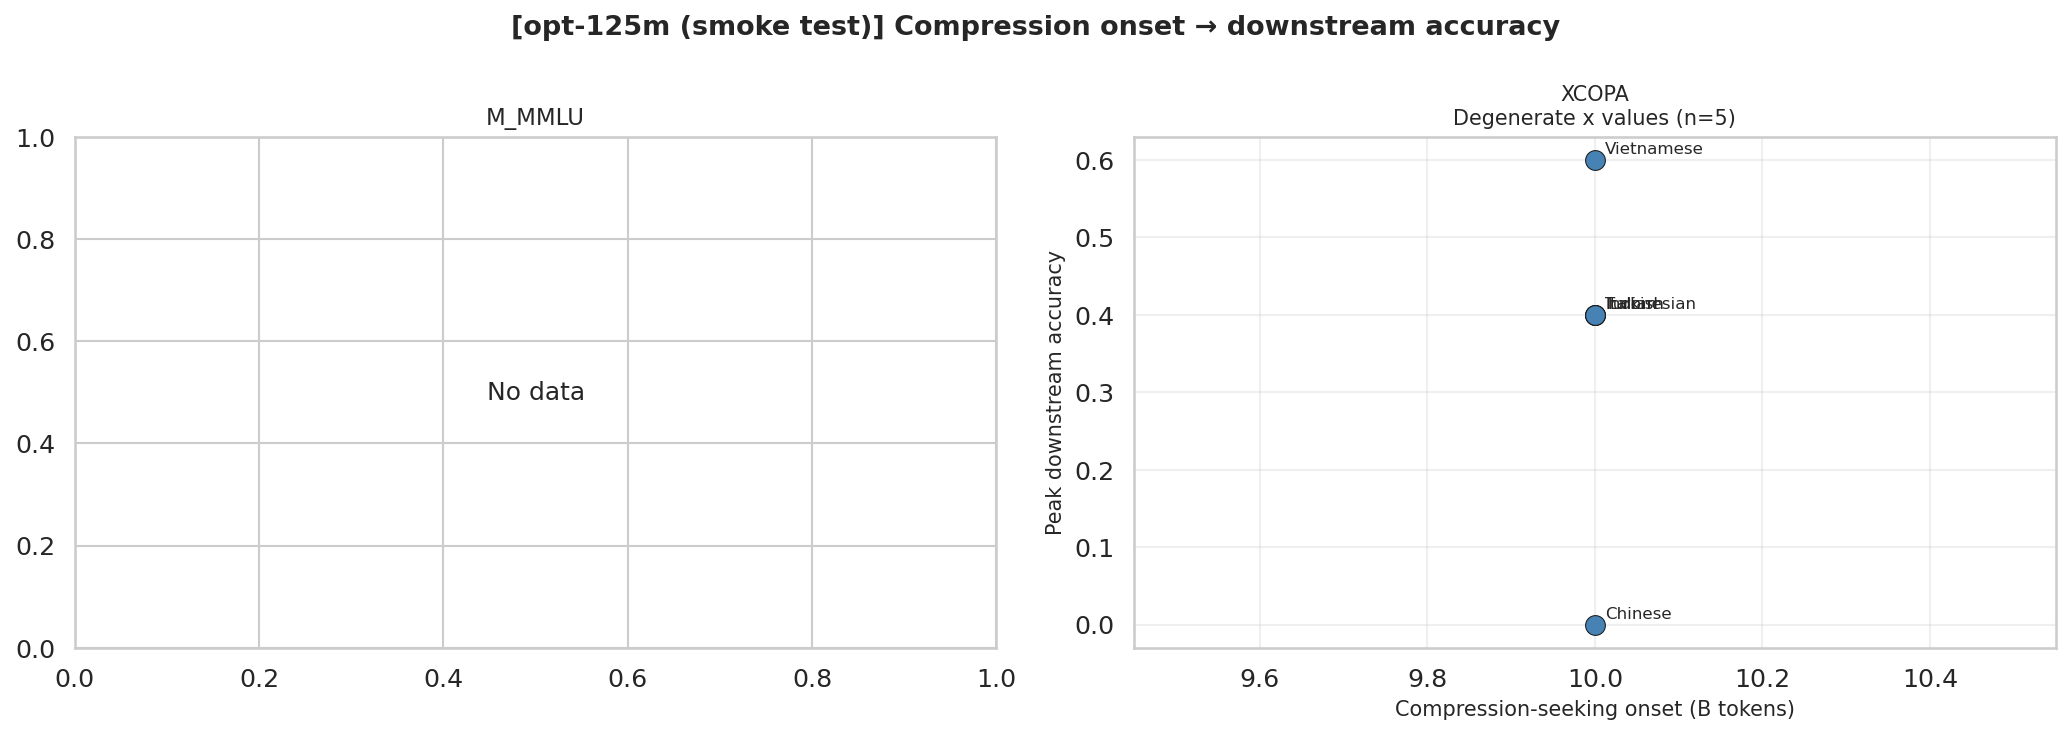

Saved: correlation_scatter.png


In [14]:
# ── Plot 4: Correlation scatter ────────────────────────────────────────────────
if EVAL_AVAILABLE and not df_correlations.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax_idx, task in enumerate(["m_mmlu", "xcopa"]):
        ax   = axes[ax_idx]
        df_t = df_grokking[df_grokking["task"] == task] if not df_grokking.empty else pd.DataFrame()
        if df_t.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12)
            ax.set_title(task.upper(), fontsize=11)
            continue
        merged = df_t.merge(
            df_phases[["language", "compression_onset_tokens"]], on="language", how="inner")
        valid  = merged.dropna(subset=["compression_onset_tokens", "peak_accuracy"])
        ax.scatter(valid["compression_onset_tokens"], valid["peak_accuracy"],
                   s=90, zorder=3, color="steelblue", edgecolors="k", lw=0.5)
        for _, row in valid.iterrows():
            ax.annotate(row["language"],
                        (row["compression_onset_tokens"], row["peak_accuracy"]),
                        fontsize=8, xytext=(5, 3), textcoords="offset points")
        title_suffix = "Insufficient data (expected — only 1 checkpoint in test)"
        if len(valid) >= 2:
            try:
                slope, intercept, r, p, _ = stats.linregress(
                    valid["compression_onset_tokens"], valid["peak_accuracy"])
                x_line = np.linspace(valid["compression_onset_tokens"].min(),
                                      valid["compression_onset_tokens"].max(), 100)
                ax.plot(x_line, slope * x_line + intercept, color="crimson",
                        alpha=0.6, lw=1.5, ls="--", label=f"r = {r:.2f}, p = {p:.3f}")
                ax.legend(fontsize=9)
                title_suffix = f"Pearson r={r:.2f}, p={p:.3f}  (n={len(valid)})"
            except ValueError:
                title_suffix = f"Degenerate x values (n={len(valid)})"
        ax.set_xlabel("Compression-seeking onset (B tokens)", fontsize=10)
        ax.set_ylabel("Peak downstream accuracy", fontsize=10)
        ax.set_title(f"{task.upper()}\n{title_suffix}", fontsize=10)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"[{MODEL_LABEL}] Compression onset → downstream accuracy",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "correlation_scatter.png")
    plt.show()
    print("Saved: correlation_scatter.png")
else:
    print("[INFO] Skipping correlation scatter — no eval data or correlations computed.")

## Test summary

If all cells ran without errors, the full pipeline is working:
- RankMe data loads correctly
- eval_test JSONs are parsed and `EVAL_AVAILABLE = True`
- Phase identification runs on all 13 languages
- Grokking detection runs (NaN results expected — only 1 checkpoint)
- Correlation table runs (n=0 expected — need ≥ 4 pairs)
- All 4 plot types render and save to `downstream_evaluation/plots_test/`

**Next step:** run the real evaluation on the cluster with `submit_eval.sh`, then switch back to `results.ipynb`.